Time series Analysis
### A Time series data is collected over the time

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
#Create Data Range
dates = pd.date_range( start = '2025-1-1', periods =365 , freq = "D")

In [4]:
#Create Components
trend = np.linspace(10,100,365)
season = 10*np.sin(np.linspace(0,50,365))
noise = np.random.normal(0,5,365)
value = trend+season+noise
value[:10]

array([ 9.55114042, 15.86410819, 13.3615146 , 14.93831718,  9.35458692,
       21.69787892, 23.72144893, 12.92630884, 26.66590169, 20.84124217])

In [5]:
df = pd.DataFrame({
    'Date':dates,
    'Price':value 
})

In [6]:
df.head()

,Date,Price
0,2025-01-01,9.551140
1,2025-01-02,15.864108
2,2025-01-03,13.361515
3,2025-01-04,14.938317
4,2025-01-05,9.354587


In [7]:
df = df.set_index('Date')

In [8]:
df.head(10)

,Price
Date,
2025-01-01,9.551140
2025-01-02,15.864108
2025-01-03,13.361515
2025-01-04,14.938317
2025-01-05,9.354587
2025-01-06,21.697879
2025-01-07,23.721449
2025-01-08,12.926309
2025-01-09,26.665902


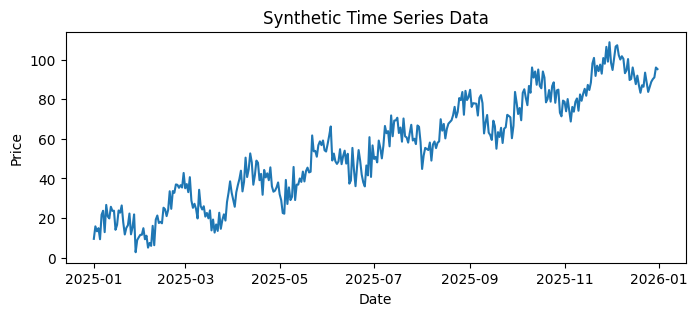

In [9]:
plt.figure(figsize=(8,3))
plt.plot(df.index , df['Price'])
plt.title('Synthetic Time Series Data')
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [10]:
!pip install statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
decompose = seasonal_decompose(df['Price'], model = 'additive', period=30)

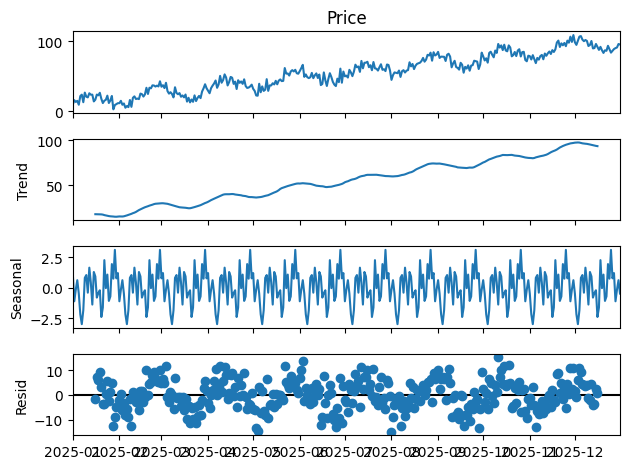

In [12]:
decompose.plot()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

In [14]:
result = adfuller(df['Price'])

In [15]:
print("P-value :", result[1])

P-value : 0.6373561758741337


In [16]:
result

(np.float64(-1.282022964344336),
 np.float64(0.6373561758741337),
 10,
 354,
 {'1%': np.float64(-3.4489583388155194),
  '5%': np.float64(-2.869739378430086),
  '10%': np.float64(-2.5711381780459)},
 np.float64(2208.162539295957))

In [17]:
df['diff']=df['Price'].diff()
df.head(3)

,Price,diff
Date,,
2025-01-01,9.551140,NaN
2025-01-02,15.864108,6.312968
2025-01-03,13.361515,-2.502594


In [18]:
df=df.dropna()

<function matplotlib.pyplot.show(close=None, block=None)>

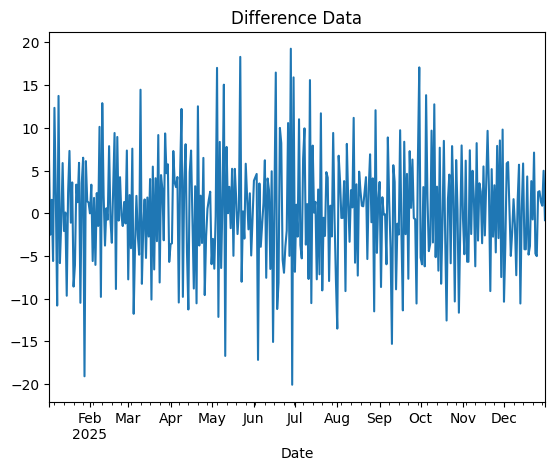

In [19]:
df['diff'].plot(title='Difference Data')
plt.show

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<function matplotlib.pyplot.show(close=None, block=None)>

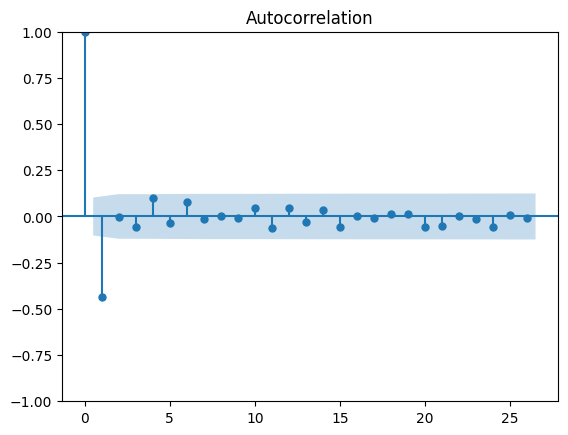

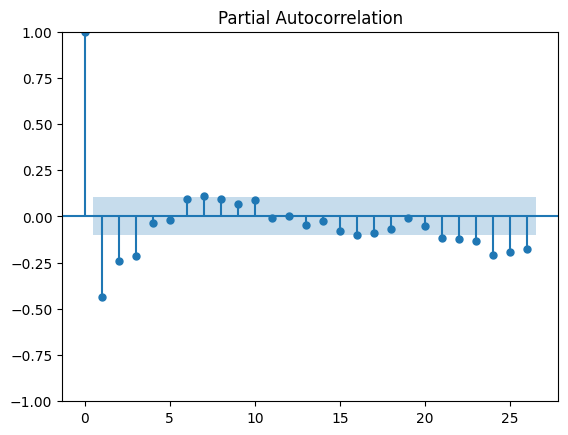

In [21]:
plot_acf(df['diff'])
plot_pacf(df['diff'])
plt.show


In [22]:
from statsmodels.tsa.arima.model import ARIMA

In [23]:
model = ARIMA(df['Price'], order=(1,1,1))
model = model.fit()

C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [44]:
forecast = model.forecast(steps=5)

In [45]:
forecast

2026-01-01    0.679626
2026-01-02    0.036009
2026-01-03    0.315701
2026-01-04    0.194157
2026-01-05    0.246976
Freq: D, Name: predicted_mean, dtype: float64

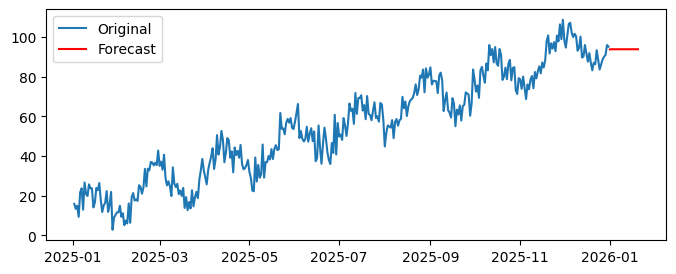

In [39]:
plt.figure(figsize=(8,3))
plt.plot(df['Price'], label="Original")
plt.plot(forecast, label="Forecast", color='red')
plt.legend()
plt.show()

In [40]:
model = ARIMA(df['diff'],order=(1,1,1))
model = model.fit()
forecast = model.forecast(steps=20)

C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


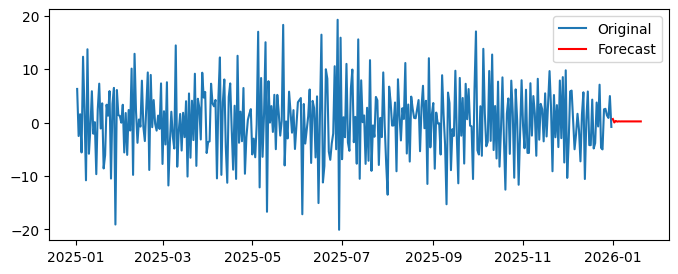

In [41]:
plt.figure(figsize=(8,3))
plt.plot(df['diff'],label="Original")
plt.plot(forecast, label="Forecast", color='red')
plt.legend()
plt.show()

In [47]:
forecast

2026-01-01    0.679626
2026-01-02    0.036009
2026-01-03    0.315701
2026-01-04    0.194157
2026-01-05    0.246976
Freq: D, Name: predicted_mean, dtype: float64

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [49]:
model_sarima = SARIMAX(df['Price'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,45))

C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Kunal Sharma\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [50]:
results = model_sarima.fit()

In [72]:
forecast_sarima = results.forecast(steps=5)

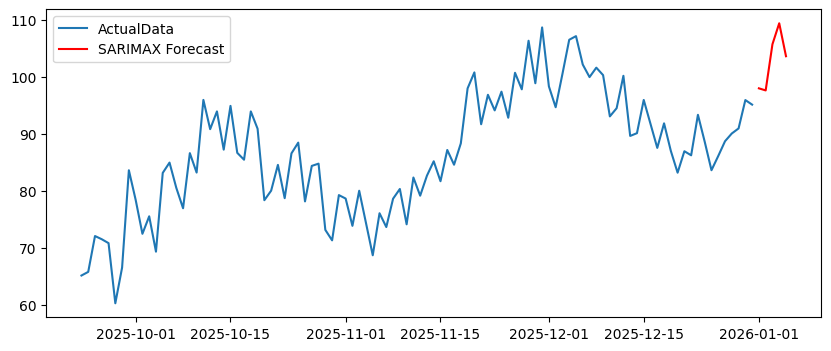

In [73]:
plt.figure(figsize=(10,4))
plt.plot(df['Price'].tail(100),label='ActualData')
plt.plot(forecast_sarima, label='SARIMAX Forecast', color='red')
plt.legend()
plt.show()

In [71]:
forecast_sarima

2026-01-01    0.679626
2026-01-02    0.036009
2026-01-03    0.315701
2026-01-04    0.194157
2026-01-05    0.246976
Freq: D, Name: predicted_mean, dtype: float64